In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/interim/calfire_topography_vegetation_weather_joined.csv")


In [ ]:
weather_cols = [
    "pr_8w",
    "rmax_8w",
    "rmin_8w",
    "sph_8w",
    "srad_8w",
    "th_8w",
    "tmmn_8w",
    "tmmx_8w",
    "vs_8w",
    "bi_8w",
    "fm100_8w",
    "fm1000_8w",
    "erc_8w",
    "etr_8w",
    "pet_8w",
    "vpd_8w",

    "pr_6w",
    "rmax_6w",
    "rmin_6w",
    "sph_6w",
    "srad_6w",
    "th_6w",
    "tmmn_6w",
    "tmmx_6w",
    "vs_6w",
    "bi_6w",
    "fm100_6w",
    "fm1000_6w",
    "erc_6w",
    "etr_6w",
    "pet_6w",
    "vpd_6w",

    "pr_4w",
    "rmax_4w",
    "rmin_4w",
    "sph_4w",
    "srad_4w",
    "th_4w",
    "tmmn_4w",
    "tmmx_4w",
    "vs_4w",
    "bi_4w",
    "fm100_4w",
    "fm1000_4w",
    "erc_4w",
    "etr_4w",
    "pet_4w",
    "vpd_4w",

    "pr_2w",
    "rmax_2w",
    "rmin_2w",
    "sph_2w",
    "srad_2w",
    "th_2w",
    "tmmn_2w",
    "tmmx_2w",
    "vs_2w",
    "bi_2w",
    "fm100_2w",
    "fm1000_2w",
    "erc_2w",
    "etr_2w",
    "pet_2w",
    "vpd_2w",
]

In [ ]:
# Base variables and lookback windows
base_vars = [
    "pr", "rmax", "rmin", "sph", "srad", "th", "tmmn", "tmmx",
    "vs", "bi", "fm100", "fm1000", "erc", "etr", "pet", "vpd"
]

windows = ["2w", "4w", "6w", "8w"]

Axes(0.125,0.712609;0.168478x0.167391) pr pr_2w
Axes(0.125,0.712609;0.168478x0.167391) pr pr_4w
Axes(0.125,0.712609;0.168478x0.167391) pr pr_6w
Axes(0.125,0.712609;0.168478x0.167391) pr pr_8w
Axes(0.327174,0.712609;0.168478x0.167391) rmax rmax_2w
Axes(0.327174,0.712609;0.168478x0.167391) rmax rmax_4w
Axes(0.327174,0.712609;0.168478x0.167391) rmax rmax_6w
Axes(0.327174,0.712609;0.168478x0.167391) rmax rmax_8w
Axes(0.529348,0.712609;0.168478x0.167391) rmin rmin_2w
Axes(0.529348,0.712609;0.168478x0.167391) rmin rmin_4w
Axes(0.529348,0.712609;0.168478x0.167391) rmin rmin_6w
Axes(0.529348,0.712609;0.168478x0.167391) rmin rmin_8w
Axes(0.731522,0.712609;0.168478x0.167391) sph sph_2w
Axes(0.731522,0.712609;0.168478x0.167391) sph sph_4w
Axes(0.731522,0.712609;0.168478x0.167391) sph sph_6w
Axes(0.731522,0.712609;0.168478x0.167391) sph sph_8w
Axes(0.125,0.511739;0.168478x0.167391) srad srad_2w
Axes(0.125,0.511739;0.168478x0.167391) srad srad_4w
Axes(0.125,0.511739;0.168478x0.167391) srad srad_6w


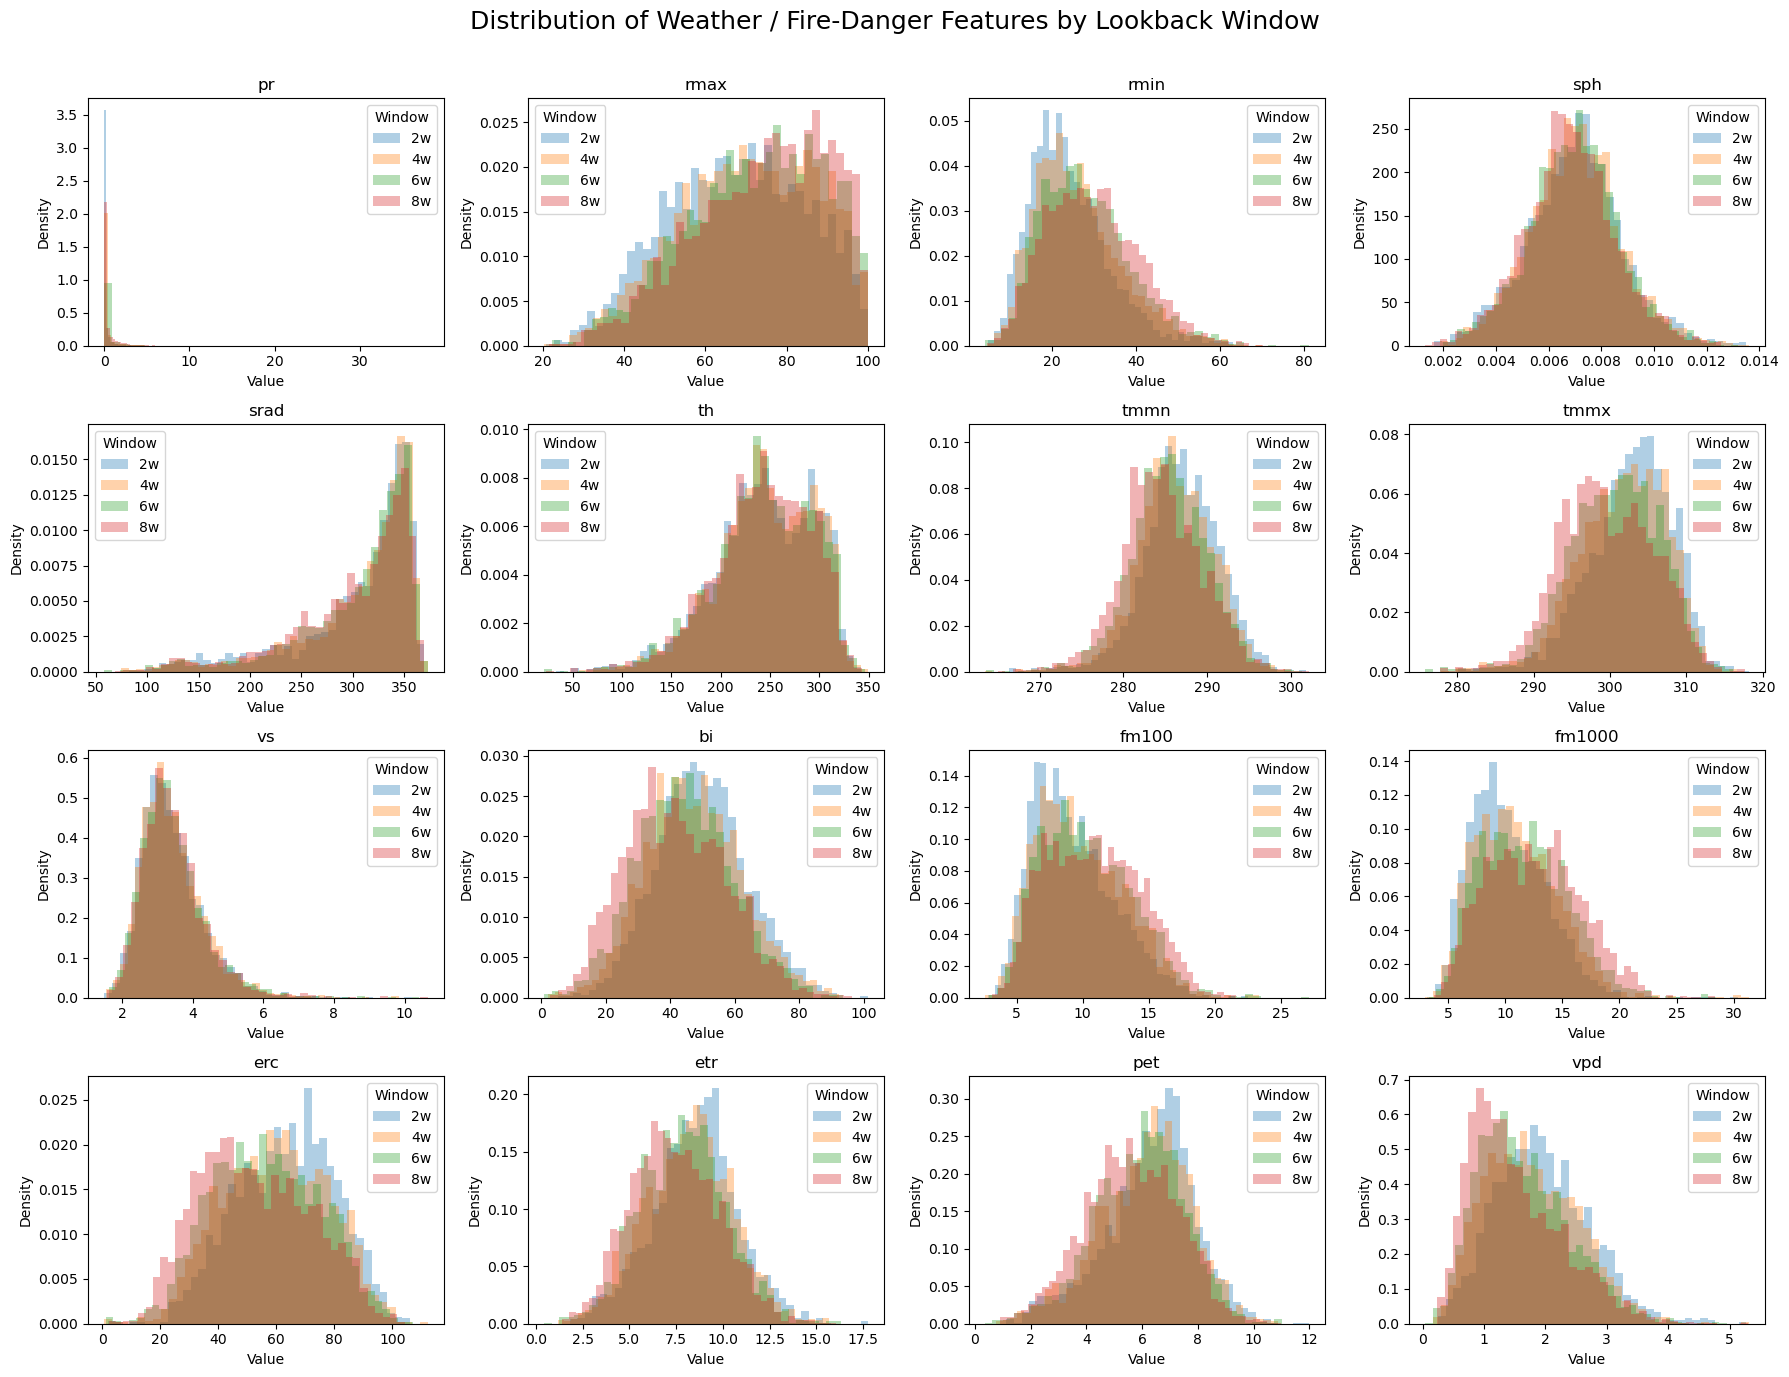

In [ ]:
# Plot feature distributions for 2/4/6/8 weeks

# Create 4x4 grid of plots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, var in zip(axes, base_vars):
    
    for window in windows:
        col = f"{var}_{window}"
        ax.hist(
            df[col].dropna(),
            bins=40,
            density=True,
            alpha=0.35,
            label=window
        )

    ax.set_title(var)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(title="Window")

plt.suptitle(
    "Distribution of Weather / Fire-Danger Features by Lookback Window",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Precipitation is strongly right skewed. Most fires have very little recent precipitation, with a few cases of higher rainfall. This makes sense because a drier environment is what usually allows a fire to start. If we want to include precipitation, consider long transforming.")

Average correlation across time windows for pr: 0.306
Average correlation across time windows for rmax: 0.772
Average correlation across time windows for rmin: 0.689
Average correlation across time windows for sph: 0.725
Average correlation across time windows for srad: 0.778
Average correlation across time windows for th: 0.731
Average correlation across time windows for tmmn: 0.780
Average correlation across time windows for tmmx: 0.739
Average correlation across time windows for vs: 0.746
Average correlation across time windows for bi: 0.773
Average correlation across time windows for fm100: 0.737
Average correlation across time windows for fm1000: 0.875
Average correlation across time windows for erc: 0.843
Average correlation across time windows for etr: 0.742
Average correlation across time windows for pet: 0.746
Average correlation across time windows for vpd: 0.715


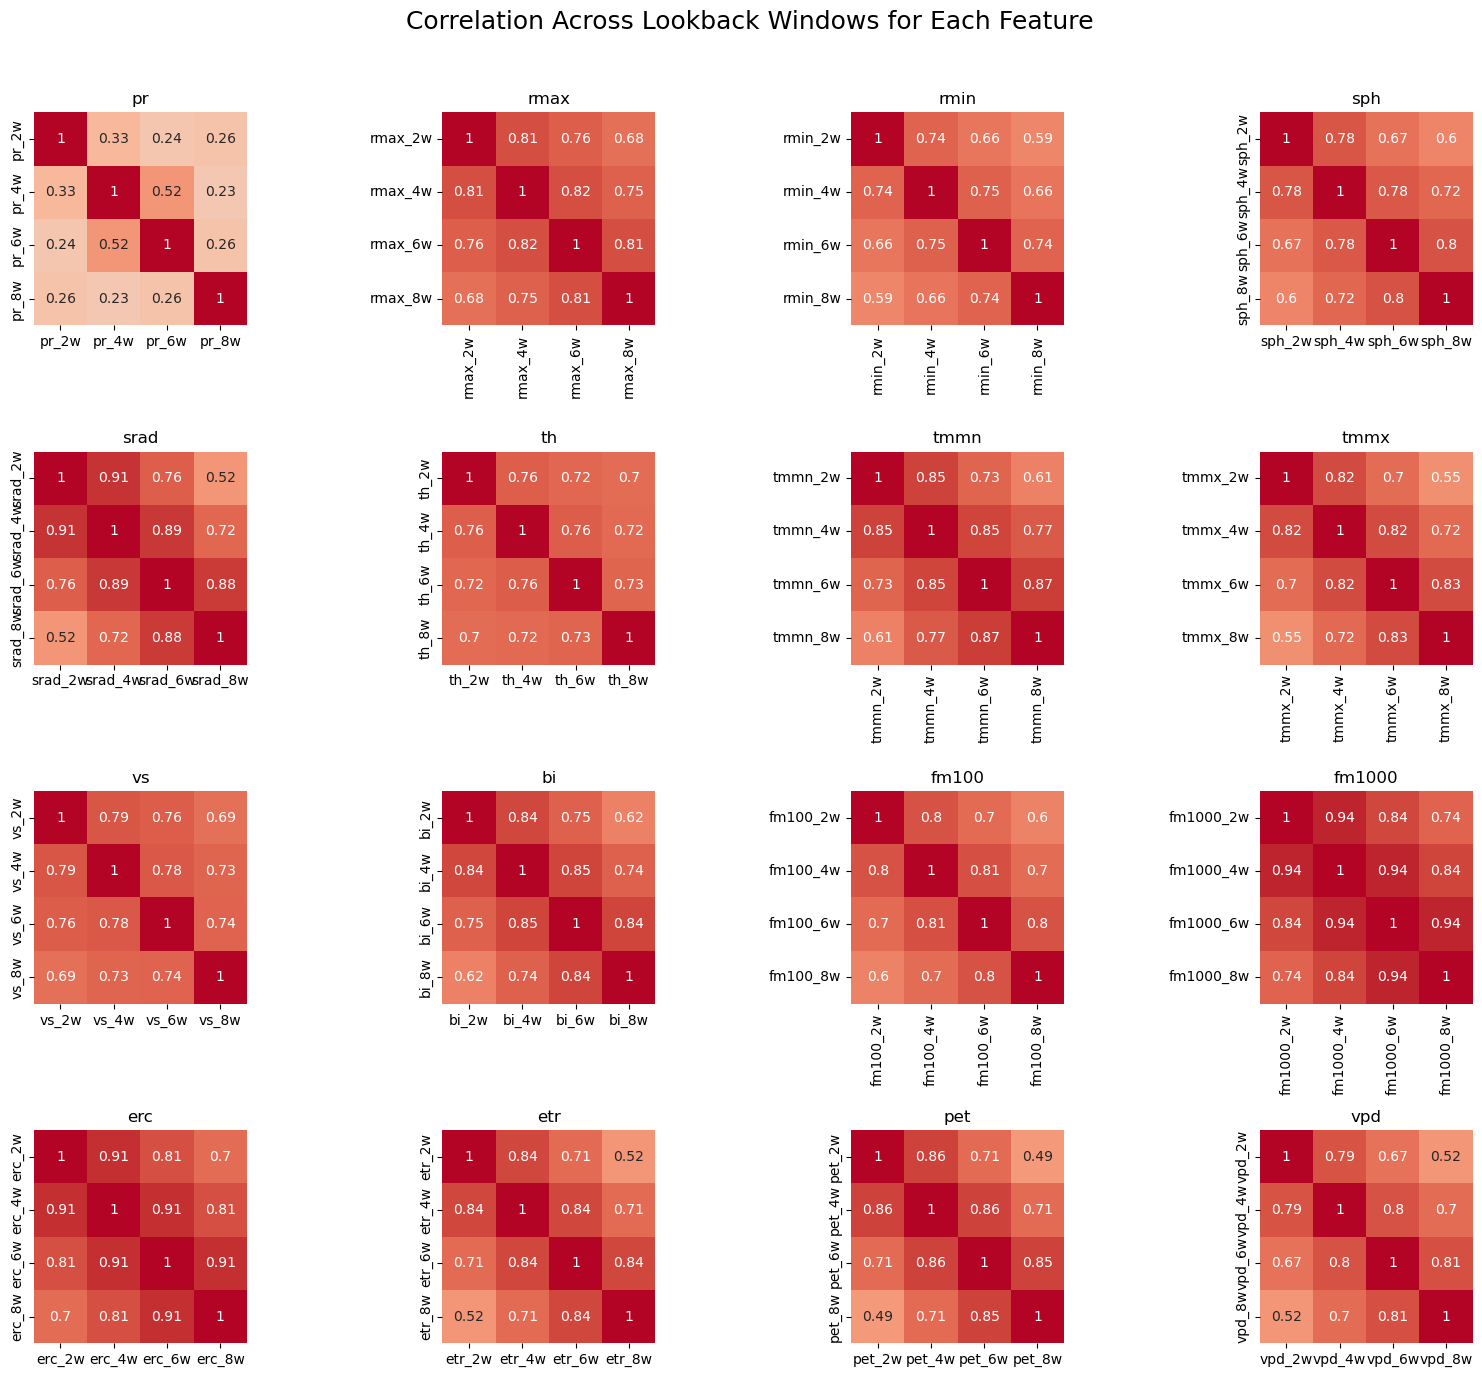

There are 2 features with low correlation across time windows, indicating independent information: pr, rmin
The rest of the features show moderate-to-high average correlation across time windows, indicating some redundancy. We can consider reducing the number of features and evaluate further during model development.


In [27]:
# Visualize time window correlations to see if they are redundant

corr = df[weather_cols].corr()

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for ax, var in zip(axes, base_vars):
    cols = [f"{var}_{w}" for w in windows]
    corr_var = df[cols].corr()
    print(f"Average correlation across time windows for {var}: {(corr_var.sum().sum()-4)/12:.3f}")

    sns.heatmap(
        corr_var,
        annot=True,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        cbar=False,
        ax=ax
    )

    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Correlation Across Lookback Windows for Each Feature", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("There are 2 features with low correlation across time windows, indicating independent information: pr, rmin")
print("The rest of the features show moderate-to-high average correlation across time windows, indicating some redundancy. We can consider reducing the number of features and evaluate further during model development.")

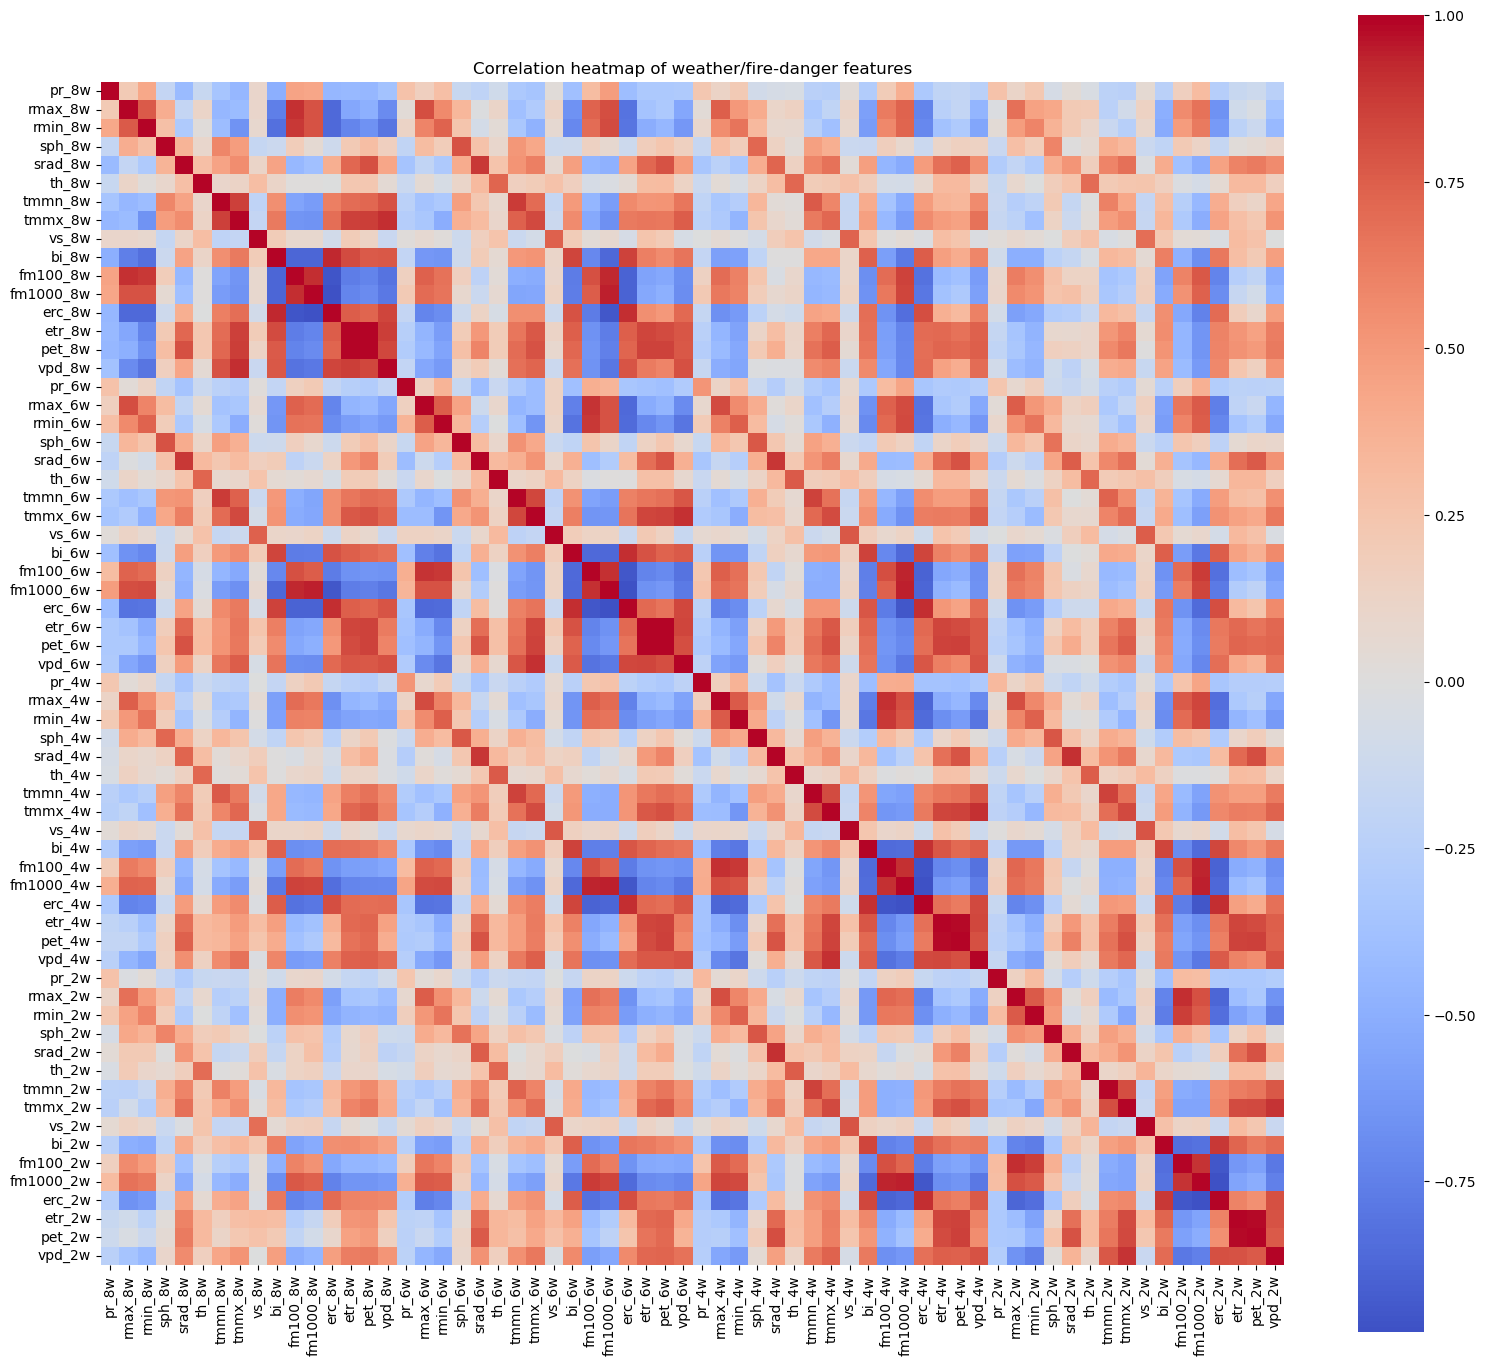

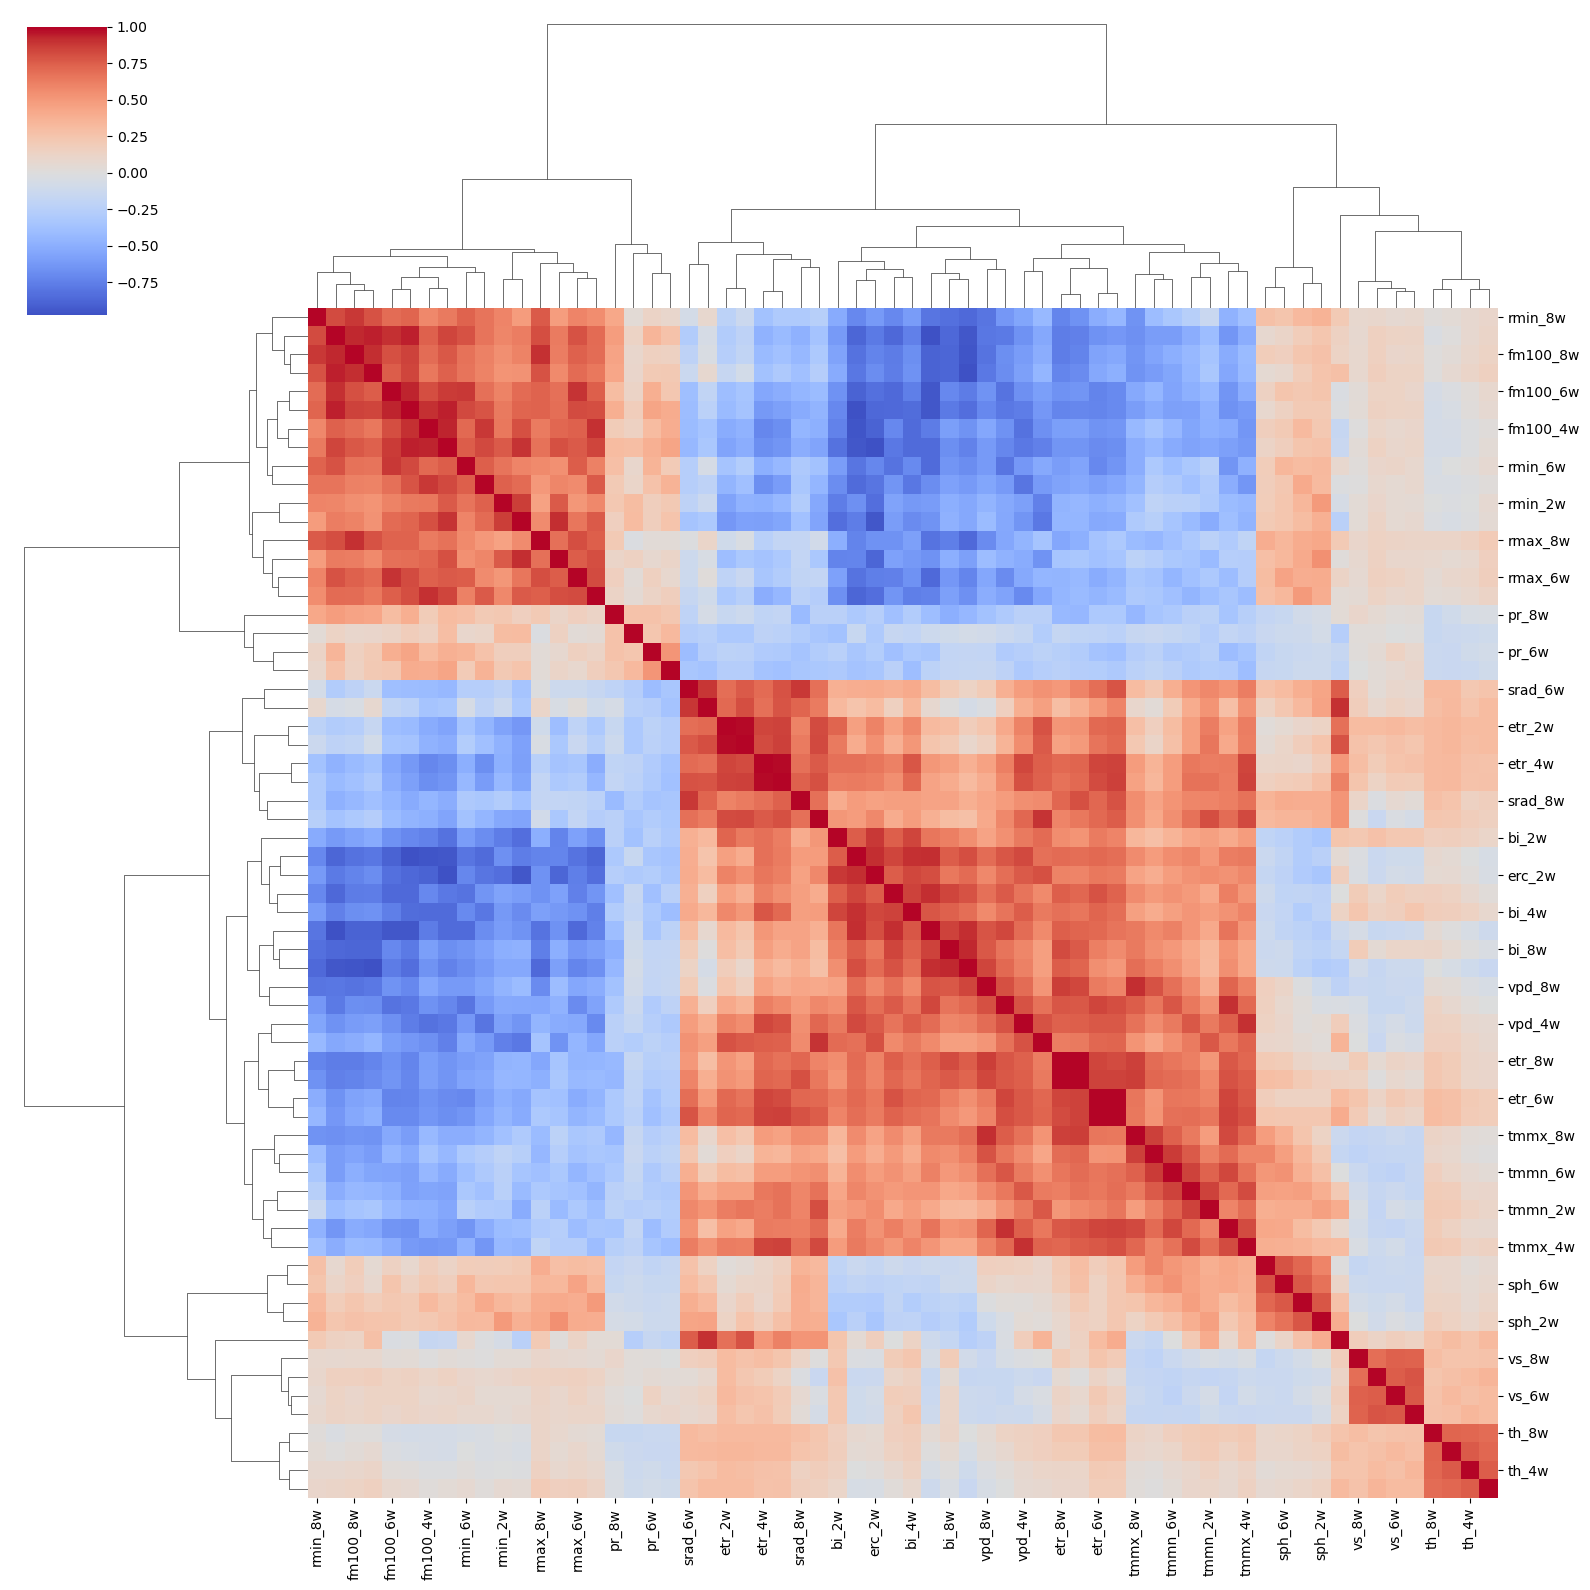

In [28]:
# corr = df[weather_cols].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap of weather/fire-danger features")
plt.tight_layout()
plt.show()

sns.clustermap(
    corr,
    cmap="coolwarm",
    center=0,
    figsize=(16, 16)
)
plt.show()